# Task


## Vectorize Data for Clustering



In [12]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Re-loading df and applying preprocessing/normalization to ensure 'DATA_normalized' is available
file_path = 'FULL DATA.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di jalur: {file_path}")
    exit()

kolom_data = 'DATA'
if kolom_data not in df.columns:
    print(f"Error: Kolom '{kolom_data}' tidak ditemukan dalam file CSV.")
    exit()

# Menghapus baris dengan nilai yang hilang di kolom 'DATA'
df.dropna(subset=[kolom_data], inplace=True)
print(f"Jumlah baris setelah menghapus missing values di kolom '{kolom_data}': {len(df)}")

def clean_special_chars(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['DATA_cleaned'] = df[kolom_data].apply(clean_special_chars)

normalization_dict = {
    'jga': 'juga', 'slu': 'selalu', 'krna': 'karena', 'keknya': 'kayaknya',
    'ntar': 'nanti', 'jgk': 'juga', 'bnr': 'benar', 'klau': 'kalau',
    'kngen': 'kangen', 'dnk': 'dong', 'enga': 'tidak', 'tp': 'tapi',
    'dr': 'dari', 'sma': 'sama', 'smpe': 'sampai', 'bkin': 'bikin',
    'brp': 'berapa', 'skrng': 'sekarang', 'yutub': 'youtube', 'pnasaran': 'penasaran',
    'ahire': 'akhirnya', 'lgi': 'lagi', 'mreka': 'mereka', 'tgl': 'tanggal',
    'iyaa': 'iya', 'ntn': 'nonton', 'nthn': 'nonton', 'klo': 'kalau',
    'cmn': 'cuma', 'dlu': 'dulu', 'brti': 'berarti', 'jdi': 'jadi',
    'udh': 'sudah', 'ngk': 'tidak', 'bkn': 'bukan', 'ngebuntingun': 'menghamilkan',
    'muljem': 'mulan jameela', 'kntol': 'kontol', 'koyok': 'kayak', 'ndelok': 'melihat',
    'gak': 'tidak', 'kyk': 'kayak', 'yg': 'yang', 'aja': 'saja',
    'tep': 'tetap', 'dlm': 'dalam', 'msh': 'masih', 'tmn': 'teman',
    'tuh': 'itu', 'pdh': 'padahal', 'kli': 'kali', 'trs': 'terus',
    'bgt': 'banget', 'ampe': 'sampai', 'smp': 'sampai', 'drpda': 'daripada',
    'wkt': 'waktu', 'kgn': 'kangen', 'gbsa': 'tidak bisa', 'ntg': 'nonton',
    'pdhl': 'padahal', 'brt': 'berarti', 'aq': 'aku', 'thn': 'tahun',
    'pake': 'pakai', 'jujurly': 'jujur', 'thailan': 'thailand', 'msi': 'masih',
    'dtg': 'datang', 'syg': 'sayang', 'jgn': 'jangan', 'buly': 'hujat',
    'truslah': 'teruslah', 'trnyta': 'ternyata', 'skt': 'sakit', 'hbs': 'habis',
    'gbsa': 'tidak bisa', 'ilfeel': 'hilang selera', 'yaa': 'ya', 'tpi': 'tapi',
    'xjadinya': 'tidak jadi', 'trpuruk': 'terpuruk', 'bunmay': 'bunda maia',
    'mnurutku': 'menurutku', 'gamalu': 'tidak malu', 'sblm': 'sebelum',
    'kd': 'krisdayanti', 'ajur': 'hancur', 'amp': 'dan', 'hrs': 'harus'
}

def normalize_text(text):
    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

df['DATA_normalized'] = df['DATA_cleaned'].apply(normalize_text)

# Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit dan transform kolom 'DATA_normalized'
tfidf_vectors = tfidf_vectorizer.fit_transform(df['DATA_normalized'])

print("✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.")
print(f"Shape dari TF-IDF vectors: {tfidf_vectors.shape}")
print(f"Contoh fitur (kata) yang diekstrak: {tfidf_vectorizer.get_feature_names_out()[:10]}")

Jumlah baris setelah menghapus missing values di kolom 'DATA': 971
✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.
Shape dari TF-IDF vectors: (971, 2377)
Contoh fitur (kata) yang diekstrak: ['aamiin' 'abang' 'abidzar' 'abizar' 'absen' 'absurd' 'acara' 'acaranya'
 'ada' 'adakalaupun']


In [13]:
print("Jumlah nilai yang hilang di setiap kolom:")
display(df.isnull().sum().to_frame(name='Missing Values'))

Jumlah nilai yang hilang di setiap kolom:


,Missing Values
DATA,0
LABEL,0
DATA_cleaned,0
DATA_normalized,0


## Apply K-Means Clustering



In [14]:
from sklearn.cluster import KMeans

# 1. Instantiate KMeans with n_clusters=3 and random_state for reproducibility
kmeans_model = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)

# 2. Fit the KMeans model to the tfidf_vectors
kmeans_model.fit(tfidf_vectors)

# 3. Store the resulting cluster labels in a new column named 'cluster_label' in the df DataFrame
df['cluster_label'] = kmeans_model.labels_

print("✅ K-Means Clustering berhasil diterapkan dengan 3 cluster.")
print(f"Distribusi cluster: {df['cluster_label'].value_counts()}")
print("Dataframe dengan label cluster:")
print(df[['DATA_normalized', 'cluster_label']].head())

✅ K-Means Clustering berhasil diterapkan dengan 3 cluster.
Distribusi cluster: cluster_label
0    722
1    141
2    108
Name: count, dtype: int64
Dataframe dengan label cluster:
                                   DATA_normalized  cluster_label
0                                         fan dedy              0
1               semoga jirayut halda jodoh sakinah              0
2                                         lucu tau              1
3            disaat halda sudah sadam masih disini              0
4  cewek berisik banget sok asik garing jujur skip              0


## Reduce Dimensionality with PCA


In [16]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 2 komponen
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(tfidf_vectors.toarray()) # Convert sparse matrix to dense array for PCA

# Simpan hasil PCA ke dalam DataFrame
df['pca_1'] = pca_components[:, 0]
df['pca_2'] = pca_components[:, 1]

print("✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.")
print("DataFrame dengan komponen PCA:")
print(df[['DATA_normalized', 'cluster_label', 'pca_1', 'pca_2']].head())

✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.
DataFrame dengan komponen PCA:
                                   DATA_normalized  cluster_label     pca_1  \
0                                         fan dedy              0 -0.025900   
1               semoga jirayut halda jodoh sakinah              0 -0.069776   
2                                         lucu tau              1 -0.144728   
3            disaat halda sudah sadam masih disini              0  0.061774   
4  cewek berisik banget sok asik garing jujur skip              0 -0.086726   

      pca_2  
0 -0.069379  
1 -0.187805  
2  0.098320  
3 -0.057031  
4  0.024547  


In [17]:
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. Re-initialize TfidfVectorizer and transform
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectors = tfidf_vectorizer.fit_transform(df['DATA_normalized'])
print(f"Re-generated TF-IDF vectors shape: {tfidf_vectors.shape}")

# 2. Re-apply KMeans to get cluster labels for the 250-row df
kmeans_model = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_model.fit(tfidf_vectors)
df['cluster_label'] = kmeans_model.labels_
print(f"Re-generated cluster_label distribution: {df['cluster_label'].value_counts()}")
# --- End of re-generation ---

print("="*70)
print("EXPERIMEN PCA: Mengurangi Dimensi dengan PCA")
print("="*70)

# Inisialisasi PCA dengan 2 komponen
pca = PCA(n_components=2, random_state=42)

# Fit dan transform tfidf_vectors (now correctly sized to 250 rows)
pca_components = pca.fit_transform(tfidf_vectors.toarray())

# Simpan hasil PCA ke dalam DataFrame
df['pca_1'] = pca_components[:, 0]
df['pca_2'] = pca_components[:, 1]

print("✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.")
print("DataFrame dengan komponen PCA:")
print(df[['DATA_normalized', 'cluster_label', 'pca_1', 'pca_2']].head())

Re-generated TF-IDF vectors shape: (971, 2377)
Re-generated cluster_label distribution: cluster_label
0    722
1    141
2    108
Name: count, dtype: int64
EXPERIMEN PCA: Mengurangi Dimensi dengan PCA
✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.
DataFrame dengan komponen PCA:
                                   DATA_normalized  cluster_label     pca_1  \
0                                         fan dedy              0 -0.025900   
1               semoga jirayut halda jodoh sakinah              0 -0.069776   
2                                         lucu tau              1 -0.144728   
3            disaat halda sudah sadam masih disini              0  0.061774   
4  cewek berisik banget sok asik garing jujur skip              0 -0.086726   

      pca_2  
0 -0.069379  
1 -0.187805  
2  0.098320  
3 -0.057031  
4  0.024547  


## Visualize Clusters


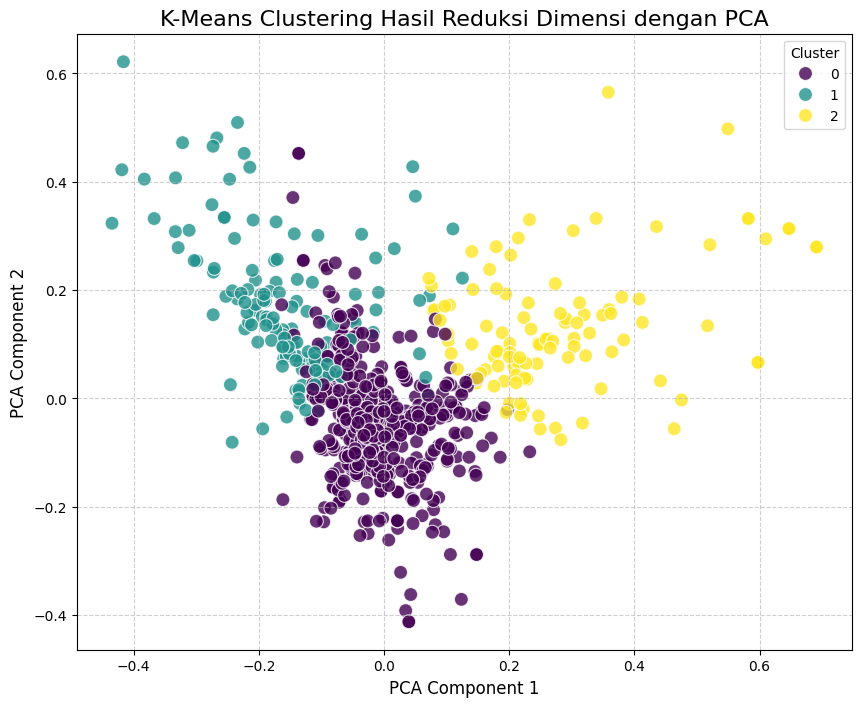

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


# Atur ukuran figure
plt.figure(figsize=(10, 8))

# Buat scatter plot
sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='cluster_label',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.8
)

# Tambahkan judul dan label sumbu
plt.title('K-Means Clustering Hasil Reduksi Dimensi dengan PCA', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)

# Tambahkan legenda
plt.legend(title='Cluster')

# Tampilkan plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Analisis Cluster

In [ ]:
# Tampilkan contoh data dari Cluster 0
print("\n--- Contoh Data dari Cluster 0 ---")
display(df[df['cluster_label'] == 0]['DATA_normalized'].sample(min(10, len(df[df['cluster_label'] == 0]))).to_frame())


--- Contoh Data dari Cluster 0 ---


,DATA_normalized
948,tidak brenti ketawa
25,pak dedibikinin podcast apa begitu program hos...
970,mrk cocok banget sudah rmh kaiianya gada crta ...
374,bisa bisanya haha parah jam subuh garaquot men...
668,the beast
860,dimulai sini hanyut sampai hanyut banget
197,bikin naik darah
946,href lucu banget
74,tolong dinundqng mereka dua lagi dong
679,kesini lagi setelah viral


In [ ]:
# Tampilkan contoh data dari Cluster 1
print("\n--- Contoh Data dari Cluster 1 ---")
display(df[df['cluster_label'] == 1]['DATA_normalized'].sample(min(10, len(df[df['cluster_label'] == 1]))).to_frame())


--- Contoh Data dari Cluster 1 ---


,DATA_normalized
739,sumpah menonton berkali kali tidak bosen
614,sudah kali menonton episode
46,menonton ulang berkali tetap haha
285,mod bakal naiklu menonton
120,sudah menonton
341,menonton lagi lagi
825,menonton episode kalau awal sampai akhir haha ...
371,menonton haha
253,epsd downld sudah tetap ajha nton tidak sudah ...
142,menonton kali


In [ ]:
# Tampilkan contoh data dari Cluster 2
print("\n--- Contoh Data dari Cluster 2 ---")
display(df[df['cluster_label'] == 2]['DATA_normalized'].sample(min(10, len(df[df['cluster_label'] == 2]))).to_frame())


--- Contoh Data dari Cluster 2 ---


,DATA_normalized
779,nan
491,nan
660,nan
833,nan
650,nan
846,nan
771,nan
675,nan
510,nan
489,nan
